### Standard VECM Model Fitting
This file calls the classes and functions declared in vecm_analysis2.py to fit the standard VECM 

The convention used in this file is:
<ul>
    <li>'um': linear perp</li>
    <li>'cm': inverse perp</li>
</ul>

In [ ]:
from vecm_analysis2 import *

Checking assumptions

In [ ]:
# checking assumptions
res = VECMResults('BTCUSDT', 'Binance', 'um')
# start date, end date, lag, coint test period, resample period, coint test period for resampled data
diag = res.get_lag_coint_multiperiod(datetime.datetime(2021,1,1), datetime.datetime(2025,1,1), 
                                     '5s', 30, '1D', '1D')

Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Error processing https://data.binance.vision/data/spot/daily/trades/BTCUSDT/BTCUSDT-trades-2024-12-18.zip: 
Error processing https://data.binance.vision/data/spot/daily/trades/BTCUSDT/BTCUSDT-trades-2024-12-20.zip: 
Fetching file list from Binance...
Fetching file list from Binance...
Fetching file list from Binance...
Fetching file list from Binance...


: 

Fitting models and saving results

In [ ]:
# running multiperiod code
res = VECMResults('BTCUSDT', 'Binance', 'um') 
# start date, end date, agg period, subset of days pulled each time, window, step, lagdur, folder name to save results
result, ff = res.get_data_multiperiod(start=datetime.datetime(2021,1,1), end=datetime.datetime(2025,12,31), 
                                      agg='1s', period=30, window='1H', step='1H', lagdur='10s', folder_name='vecm_results2_um')

File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, reading files...
File found, re

Intraday error correction plot

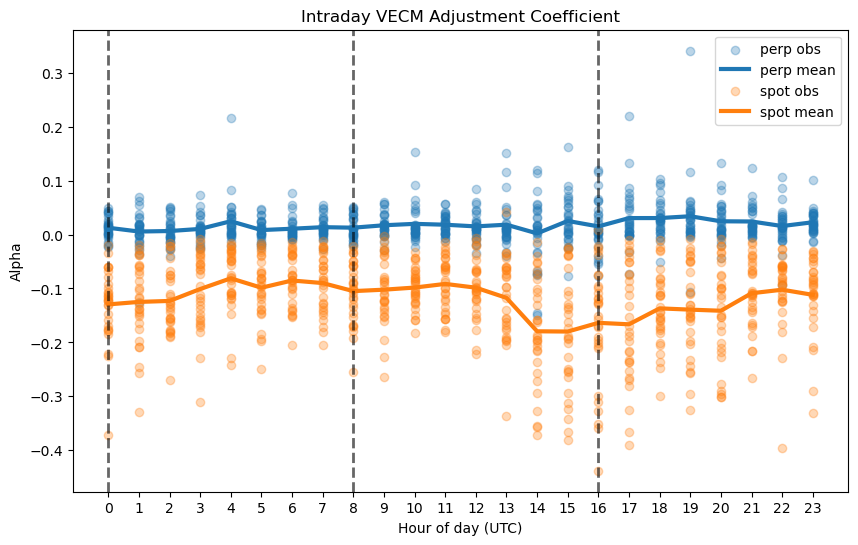

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# df = result[result['ils_valid']].copy()
df = result.copy()

# ensure datetime
df['interval'] = pd.to_datetime(df['window_start'])
df['hour'] = df['interval'].dt.hour

# reshape wide -> long for alpha columns
df_long = df.melt(
    id_vars=['interval', 'hour'],
    value_vars=['alpha_spot', 'alpha_perp'],
    var_name='series',
    value_name='alpha'
)

# clean series labels
df_long['series'] = df_long['series'].str.replace('alpha_', '', regex=False)
# df_long['alpha'] = df_long['alpha'].abs()

# mean alpha by hour and series
mean_alpha = (
    df_long.groupby(['hour', 'series'])['alpha']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for series, g in df_long.groupby('series'):
    # scatter observations
    ax.scatter(
        g['hour'],
        g['alpha'],
        alpha=0.3,
        label=f"{series} obs"
    )

    # mean line
    m = mean_alpha[mean_alpha['series'] == series]
    ax.plot(
        m['hour'],
        m['alpha'],
        linewidth=3,
        label=f"{series} mean"
    )

# funding payment times
for f in [0, 8, 16]:
    ax.axvline(
        x=f,
        linestyle='--',
        linewidth=2,
        alpha=0.6,
        color='k'
    )

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel(r"Alpha")
ax.set_title("Intraday VECM Adjustment Coefficient")
ax.set_xticks(range(24))
ax.legend()
plt.show()


Information leadership share plot

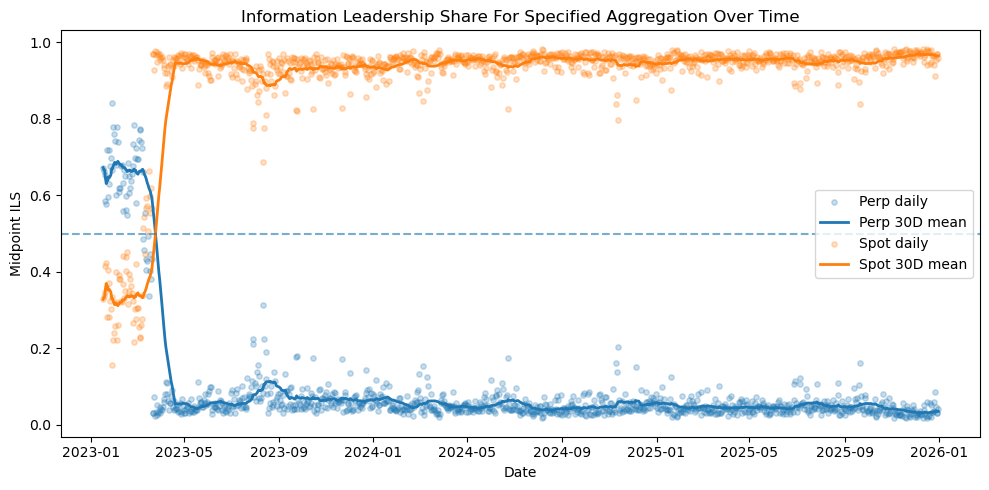

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

results_i = result.copy()

# ensure datetime
results_i['window_start'] = pd.to_datetime(results_i['window_start'])
results_i['window_end'] = pd.to_datetime(results_i['window_end'])

# use window_start as the plotting timestamp
results_i['date'] = results_i['window_start'].dt.date

# daily means
daily = (
    results_i.groupby('date', as_index=False)[['ils_mid_spot', 'ils_mid_perp']]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

daily = daily.sort_values('date').copy()


# perp
ax.scatter(
    daily['date'],
    daily['ils_mid_perp'],
    alpha=0.25,
    s=15,
    label='Perp daily'
)
ax.plot(
    daily['date'],
    daily['ils_mid_perp'].rolling(window=window, min_periods=1).mean(),
    linewidth=2,
    label=f'Perp {window}D mean'
)

# spot
ax.scatter(
    daily['date'],
    daily['ils_mid_spot'],
    alpha=0.25,
    s=15,
    label='Spot daily'
)
ax.plot(
    daily['date'],
    daily['ils_mid_spot'].rolling(window=window, min_periods=1).mean(),
    linewidth=2,
    label=f'Spot {window}D mean'
)


ax.axhline(0.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint ILS')
ax.legend()
plt.title('Information Leadership Share For Specified Aggregation Over Time')
plt.tight_layout()
plt.show()

Selected lag order plot

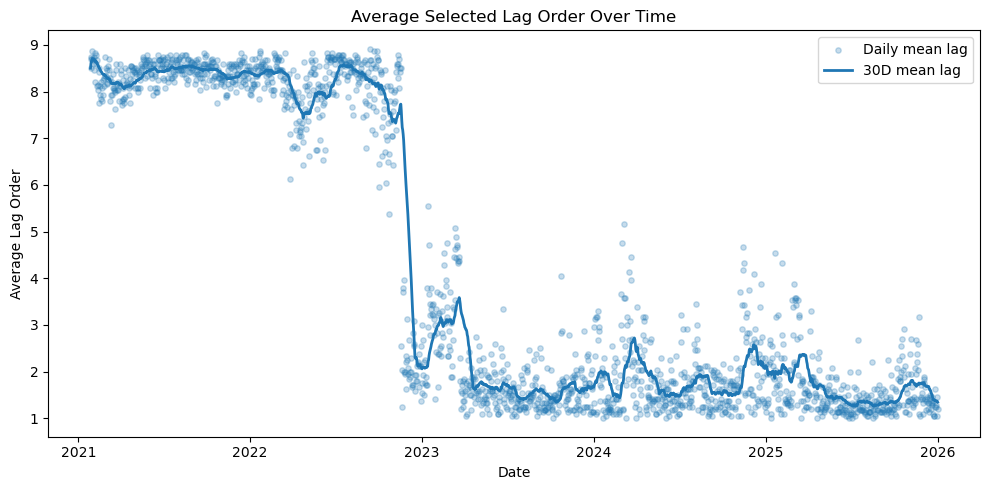

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

results_i = result.copy()

# ensure datetime
results_i['window_start'] = pd.to_datetime(results_i['window_start'])
results_i['window_end'] = pd.to_datetime(results_i['window_end'])

# use window_start as the plotting timestamp
results_i['date'] = results_i['window_start'].dt.date

# daily mean lag order
daily = (
    results_i.groupby('date', as_index=False)[['lag_order']]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

daily = daily.sort_values('date').copy()

# daily mean lag order
ax.scatter(
    daily['date'],
    daily['lag_order'],
    alpha=0.25,
    s=15,
    label='Daily mean lag'
)

# rolling mean
ax.plot(
    daily['date'],
    daily['lag_order'].rolling(window=window, min_periods=1).mean(),
    linewidth=2,
    label=f'{window}D mean lag'
)

ax.set_xlabel('Date')
ax.set_ylabel('Average Lag Order')
ax.legend()
plt.title('Average Selected Lag Order Over Time')
plt.tight_layout()
plt.show()